# Discreteness thresholds: the crowding-budget model, across every configuration

This notebook exists to **tune the discreteness thresholds by eye**. It walks
through every data configuration and shows what the default plot does as the
**number of distinct (unique) values crosses the threshold** — the sample size
is held large (`n = 5000`) throughout, so the only thing moving is the unique
count. The threshold values are **provisional**; the point is to look at these
plots and decide whether `B_1D` and `K_2D` should change.

**How the default is chosen.** `classify_data(values)` labels each variable via
a dtype gate plus a count budget:

- categorical/string → always discrete (a category can't be binned);
- all-distinct float → always continuous;
- otherwise (integers, repeated floats) → discrete iff `n_unique <= budget`.

The **budget** depends on the plot's dimensionality — because crowding does:

- **`B_1D`** — a 1-D plot shows `k` marks (impulse stems / dots), so its budget
  is on `k` directly.
- **`K_2D`** — a 2-D plot shows a grid, so each axis is judged **independently**
  against a per-axis cap. Both axes discrete → **tile**; one over →
  **mixed tile** (that axis binned); both over → **2-D histogram**.

Both budgets are anchored to the default histogram bin count (30): a discrete
plot stays discrete exactly while it is no finer than the 30-bin histogram it
would otherwise become. That makes `B_1D` and `K_2D` the same number (30) with
a reason behind it, not a guess.

`(configuration, small_n)` then indexes `DEFAULT_PLOT_TYPE`. At large `n`:

| configuration | discrete side | continuous side |
|---|---|---|
| 1-D numeric | impulse | histogram |
| 2-D, per axis | tile (both discrete) / mixed tile (one binned) | 2-D histogram (both binned) |

The threshold is passed in at the dispatch layer: `results.py` uses `B_1D` for
1-D and `K_2D` per axis for 2-D. See `DECISIONS.md`, "classify_data Thresholds
(Budget Model)".

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from symbulate import *
from symbulate.plot import classify_data, B_1D, K_2D, N_SMALL_THRESHOLD

print("B_1D =", B_1D, " (1-D discreteness budget: max impulse/dot marks)")
print("K_2D =", K_2D, " (2-D per-axis cap: max cells per axis before binning)")
print("N_SMALL_THRESHOLD =", N_SMALL_THRESHOLD, " (small/large-n crossover)")

N = 5000   # held large the whole notebook, so only the unique count matters

B_1D = 30  (1-D discreteness budget: max impulse/dot marks)
K_2D = 30  (2-D per-axis cap: max cells per axis before binning)
N_SMALL_THRESHOLD = 100  (small/large-n crossover)


## The helper

`show(sims)` reports each variable's unique count and how it is classified, then
draws the default plot. It classifies exactly as `.plot()` does: `B_1D` for 1-D,
`K_2D` per axis for 2-D. `suggest=True` prints the "Currently Showing: …
(Default)" line so you can read the chosen default directly.

In [2]:
def show(sims):
    """Report classify_data's verdict for `sims` (matching .plot()), then draw it."""
    data = np.asarray(list(sims))
    if data.ndim == 1:
        n, k = len(data), len(set(data))
        discrete_ish, _ = classify_data(data, n_unique_threshold=B_1D)
        kind = "discrete-ish" if discrete_ish else "continuous-ish"
        print(f"1D:  n = {n},  unique = {k}  (budget B_1D = {B_1D})  ->  {kind}")
    else:
        x, y = data[:, 0], data[:, 1]
        dx, _ = classify_data(x, n_unique_threshold=K_2D)
        dy, _ = classify_data(y, n_unique_threshold=K_2D)
        xkind = "discrete" if dx else "continuous"
        ykind = "discrete" if dy else "continuous"
        if dx and dy:
            cfg = "2D discrete x discrete"
        elif not dx and not dy:
            cfg = "2D continuous x continuous"
        else:
            cfg = "2D mixed"
        print(
            f"2D:  x unique = {len(set(x))} ({xkind}),  y unique = {len(set(y))} "
            f"({ykind})  (per-axis cap K_2D = {K_2D})  ->  {cfg}"
        )
    plt.figure()
    sims.plot(suggest=True)
    plt.show()

# Configurations that cross the threshold

## 1. 1-D numeric — impulse → histogram (budget `B_1D`)

`BoxModel([0, 1, …, k-1])` gives exactly `k` unique integer values at large `n`.
The boundary is `B_1D`: `k <= B_1D` stays an impulse plot, `k > B_1D` becomes a
histogram. (Ranges are written relative to `B_1D` so this stays correct if you
retune it.)

1D:  n = 5000,  unique = 30  (budget B_1D = 30)  ->  discrete-ish
Currently Showing: Impulse Plot (Default)
Alternative Plots: Histogram (type = "hist"), Dot Plot (type = "dotplot"), ECDF Plot (type = "ecdf")


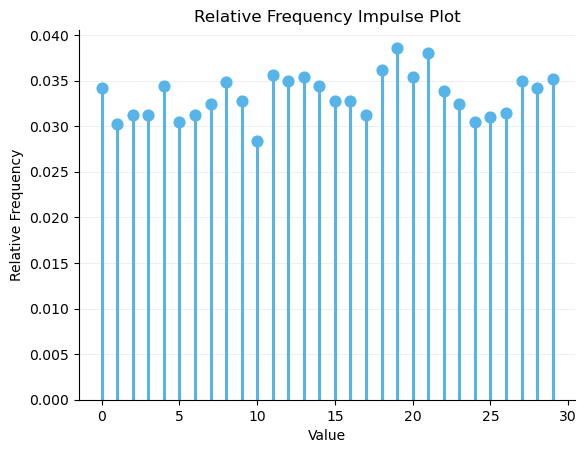

1D:  n = 5000,  unique = 31  (budget B_1D = 30)  ->  continuous-ish
Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


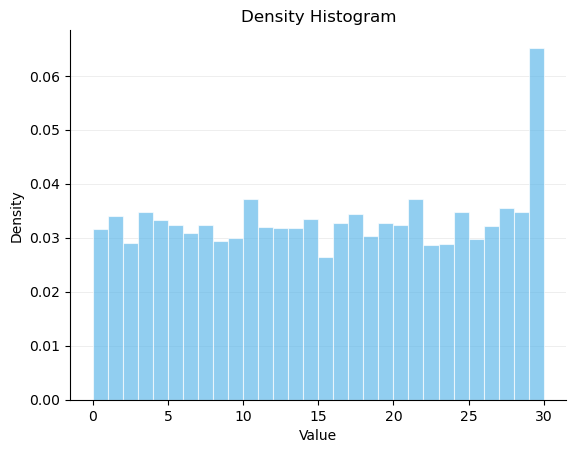

In [3]:
show(RV(BoxModel(list(range(B_1D)))).sim(N))       # k = B_1D      -> impulse
show(RV(BoxModel(list(range(B_1D + 1)))).sim(N))   # k = B_1D + 1  -> histogram

**Floats behave the same** as long as values repeat; the cutoff is still
`B_1D`. (All-distinct floats, like a raw `Normal()` sample, are always
continuous — configuration 4.) And with a **real distribution**, a Poisson's
spread of distinct values grows with its rate, walking it across the boundary.
*(Process time points like `PoissonProcess(rate)[t].sim(n)` are ordinary 1-D
numeric results and follow this same rule.)*

1D:  n = 5000,  unique = 12  (budget B_1D = 30)  ->  discrete-ish
Currently Showing: Impulse Plot (Default)
Alternative Plots: Histogram (type = "hist"), Dot Plot (type = "dotplot"), ECDF Plot (type = "ecdf")


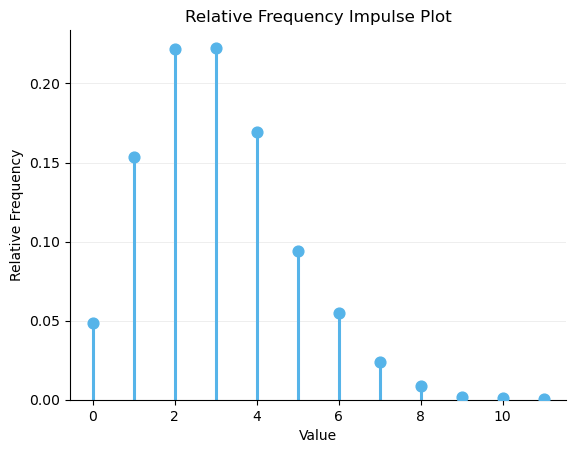

1D:  n = 5000,  unique = 62  (budget B_1D = 30)  ->  continuous-ish
Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


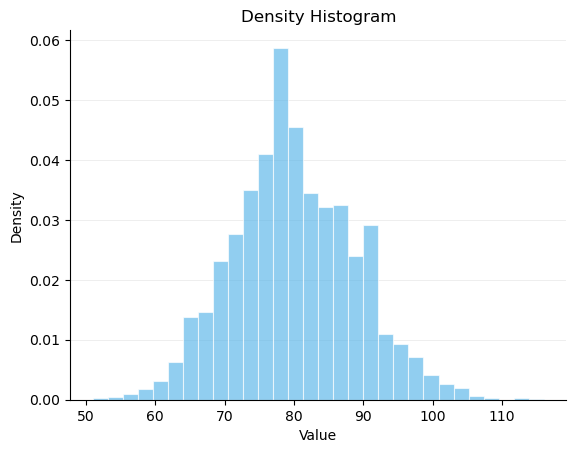

In [4]:
show(RV(Poisson(3)).sim(N))    # few unique -> impulse
show(RV(Poisson(80)).sim(N))   # many unique -> histogram

## 2. 2-D discrete × discrete — per-axis independence (cap `K_2D`)

Each axis is judged independently against `K_2D`. Watch the four cases: both
small, both at the cap, one over, both over. **This is the key section for
tuning `K_2D`** — look at the `K_2D × K_2D` tile below and decide whether it is
still readable or already too crowded.

2D:  x unique = 5 (discrete),  y unique = 5 (discrete)  (per-axis cap K_2D = 30)  ->  2D discrete x discrete
Currently Showing: Tile Plot (Default)
Alternative Plots: Scatter Plot (type = "scatter"), Mosaic Plot (type = "mosaic")


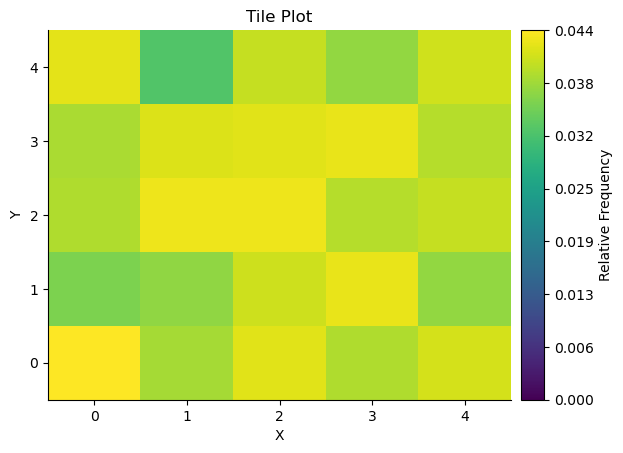

In [5]:
show(RV(BoxModel(list(range(5))) * BoxModel(list(range(5)))).sim(N))          # both small -> tile

2D:  x unique = 30 (discrete),  y unique = 30 (discrete)  (per-axis cap K_2D = 30)  ->  2D discrete x discrete
Currently Showing: Tile Plot (Default)
Alternative Plots: Scatter Plot (type = "scatter"), Mosaic Plot (type = "mosaic")


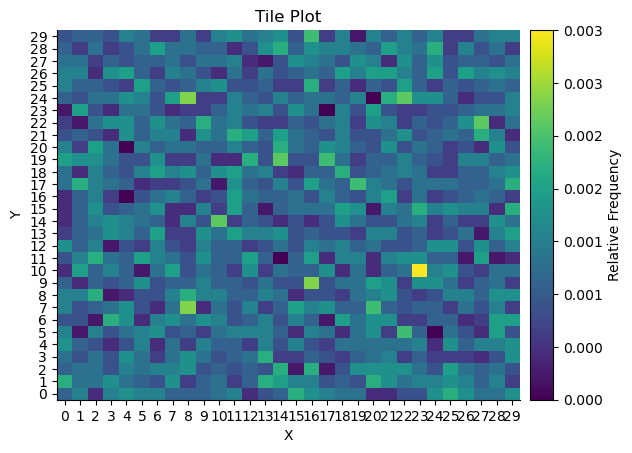

In [6]:
show(RV(BoxModel(list(range(K_2D))) * BoxModel(list(range(K_2D)))).sim(N))    # both = K_2D -> tile (largest tile drawn)

2D:  x unique = 5 (discrete),  y unique = 40 (continuous)  (per-axis cap K_2D = 30)  ->  2D mixed
Currently Showing: Tile Plot (Default)
Alternative Plots: Rug Plot (type = "rug"), Box Plot (type = "box"), Violin Plot (type = "violin"), Density Plot (type = "density"), Histogram (type = "hist")


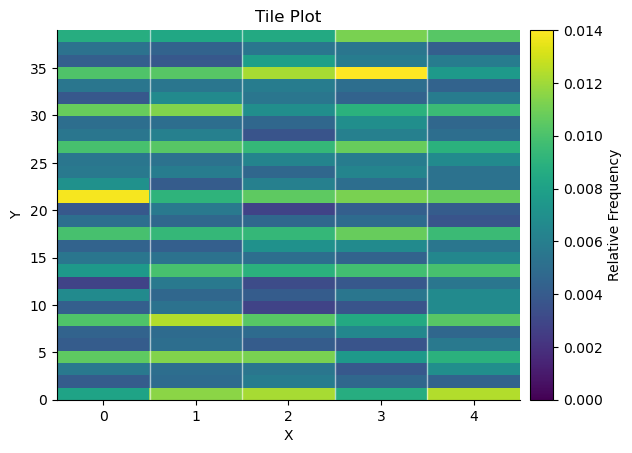

In [7]:
show(RV(BoxModel(list(range(5))) * BoxModel(list(range(K_2D + 10)))).sim(N))  # one over -> mixed tile (INTERMEDIATE)

2D:  x unique = 40 (continuous),  y unique = 40 (continuous)  (per-axis cap K_2D = 30)  ->  2D continuous x continuous
Currently Showing: 2D Histogram (Default)
Alternative Plots: 2D Density Plot (type = "density2d"), Scatter Plot (type = "scatter")


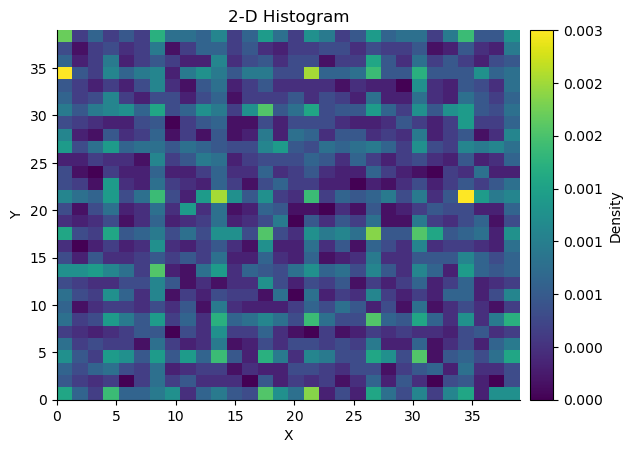

In [8]:
show(RV(BoxModel(list(range(K_2D + 10))) * BoxModel(list(range(K_2D + 10)))).sim(N))  # both over -> 2-D histogram

## 3. 2-D mixed (discrete × continuous) — cap `K_2D` on the discrete axis

One axis is continuous already; the other is discrete. When the discrete axis's
unique count crosses `K_2D`, it too is binned, so the pair becomes continuous ×
continuous → 2-D histogram.

2D:  x unique = 30 (discrete),  y unique = 5000 (continuous)  (per-axis cap K_2D = 30)  ->  2D mixed
Currently Showing: Tile Plot (Default)
Alternative Plots: Rug Plot (type = "rug"), Box Plot (type = "box"), Violin Plot (type = "violin"), Density Plot (type = "density"), Histogram (type = "hist")


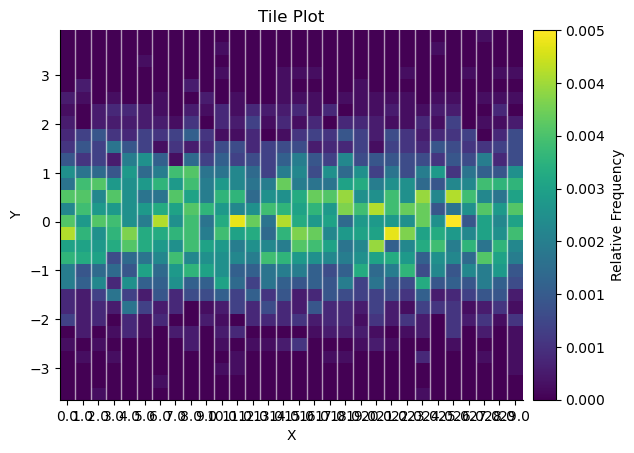

2D:  x unique = 40 (continuous),  y unique = 5000 (continuous)  (per-axis cap K_2D = 30)  ->  2D continuous x continuous
Currently Showing: 2D Histogram (Default)
Alternative Plots: 2D Density Plot (type = "density2d"), Scatter Plot (type = "scatter")


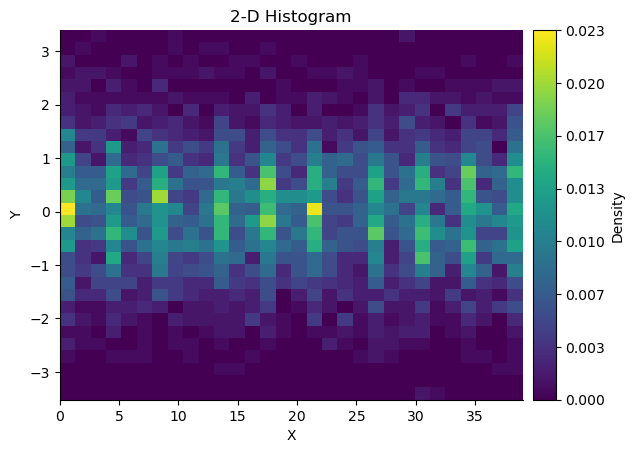

In [9]:
show(RV(BoxModel(list(range(K_2D))) * Normal()).sim(N))       # discrete axis = K_2D  -> tile (mixed)
show(RV(BoxModel(list(range(K_2D + 10))) * Normal()).sim(N))  # discrete axis over K_2D -> 2-D histogram

# Configurations that never cross

## 4. 2-D continuous × continuous — always a 2-D histogram

All-distinct float axes are continuous by construction, so there is no unique
count to cut off.

2D:  x unique = 5000 (continuous),  y unique = 5000 (continuous)  (per-axis cap K_2D = 30)  ->  2D continuous x continuous
Currently Showing: 2D Histogram (Default)
Alternative Plots: 2D Density Plot (type = "density2d"), Scatter Plot (type = "scatter")


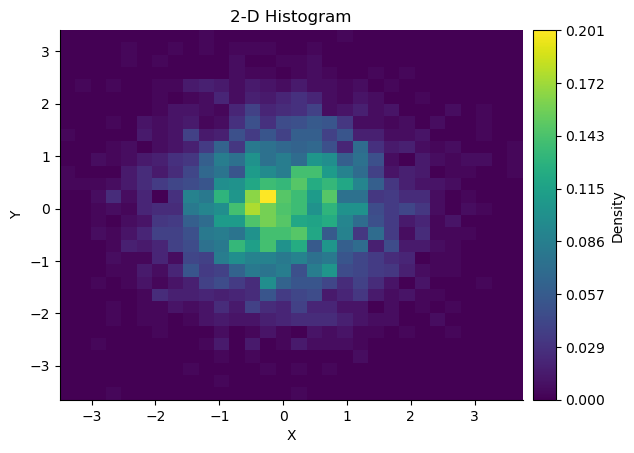

In [10]:
show(RV(Normal() * Normal()).sim(N))   # continuous x continuous -> 2-D histogram

## 5. 1-D categorical / string — always a bar chart

String outcomes are `object`-dtype, which `classify_data` **always** treats as
discrete, regardless of how many categories there are (a category can't be
binned). So 3 categories and 60 categories both stay a bar chart — compare that
with 60 *integers*, which exceed `B_1D` and become a histogram: same count,
opposite result, purely because of dtype.

1D:  n = 5000,  unique = 3  (budget B_1D = 30)  ->  discrete-ish
Currently Showing: Bar Chart (Default)
Alternative Plots: Dot Plot (type = "dotplot"), Impulse Plot (type = "impulse")


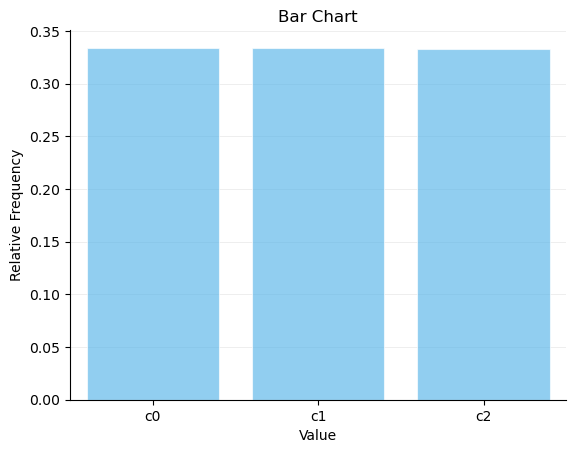

1D:  n = 5000,  unique = 60  (budget B_1D = 30)  ->  discrete-ish


Currently Showing: Bar Chart (Default)
Alternative Plots: Dot Plot (type = "dotplot"), Impulse Plot (type = "impulse")


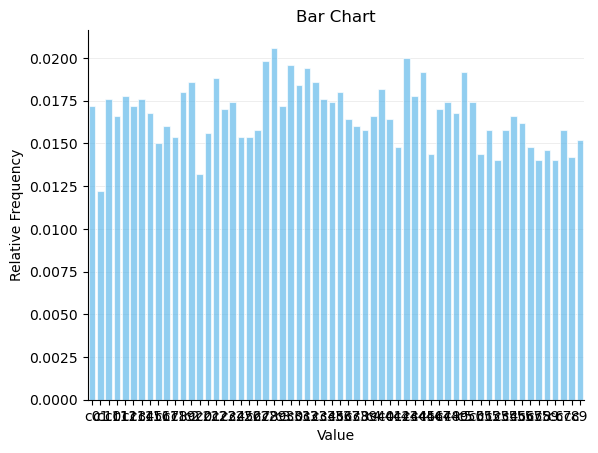

In [11]:
show(RV(BoxModel([f"c{i}" for i in range(3)])).sim(N))    # 3 categories  -> bar
show(RV(BoxModel([f"c{i}" for i in range(60)])).sim(N))   # 60 categories -> still bar (exempt)

# Summary

Holding `n` large, as a variable's unique count crosses its budget:

| Configuration | discrete side | continuous side | budget |
|---|---|---|---|
| 1-D numeric | impulse | histogram | `k <= B_1D` |
| 2-D discrete × discrete | tile | one axis over → mixed tile; both over → 2-D histogram | per axis `k <= K_2D` |
| 2-D mixed (disc × cont) | tile | 2-D histogram (once the discrete axis crosses) | discrete axis `k <= K_2D` |
| 2-D continuous × continuous | — | 2-D histogram (always) | NA |
| 1-D categorical / string | bar (always) | — | NA (exempt) |

`B_1D` and `K_2D` are provisional. The tuning question: in configuration 2, is
the `K_2D × K_2D` tile still readable, or should `K_2D` come down? Edit the
constants at the top of `symbulate/plot.py` and re-run.